# SmartCare Hospital AI Coursework
## Task 06 — Model Evaluation, Calibration, and Fairness

**Objective:** Evaluate the model fixed in Task 05 using one final pass on the untouched test set. Probability calibration is fitted on validation data only. Test data is never used to tune or select the model.

## 6.1 Import Libraries

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss, roc_curve
)
try:
    from sklearn.frozen import FrozenEstimator
    HAS_FROZEN = True
except ImportError:
    HAS_FROZEN = False

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
# Run Colab/VS Code from the cloned repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models_checkpoints'

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## 6.2 Load Fixed Models and Data Splits

In [2]:
metadata = json.loads((MODEL_DIR / 'selected_model_info.json').read_text())
selected_model_name = metadata['selected_model']
decision_threshold = float(metadata['decision_threshold'])

model_files = {
    'Logistic Regression': 'logistic_regression_pipeline.pkl',
    'Random Forest': 'random_forest_pipeline.pkl',
    'Gradient Boosting': 'gradient_boosting_pipeline.pkl',
    'SVM (RBF)': 'svm_rbf_pipeline.pkl'
}
models = {name: joblib.load(MODEL_DIR / filename) for name, filename in model_files.items()}
selected_model = joblib.load(MODEL_DIR / 'selected_model_pipeline.pkl')

X_val = pd.read_csv(MODEL_DIR / 'X_val.csv')
y_val = pd.read_csv(MODEL_DIR / 'y_val.csv').iloc[:, 0]
X_test = pd.read_csv(MODEL_DIR / 'X_test.csv')
y_test = pd.read_csv(MODEL_DIR / 'y_test.csv').iloc[:, 0]
fair_test = pd.read_csv(MODEL_DIR / 'fair_test.csv')

assert X_val.columns.tolist() == metadata['feature_columns']
assert X_test.columns.tolist() == metadata['feature_columns']
assert len(X_test) == len(y_test) == len(fair_test)

print('Selected model:', selected_model_name)
print('Fixed threshold:', decision_threshold)
print('Validation set:', X_val.shape)
print('Final test set:', X_test.shape)

Selected model: Random Forest
Fixed threshold: 0.39
Validation set: (175, 24)
Final test set: (175, 24)


## 6.3 Fit Probability Calibration on Validation Data

In [3]:
if HAS_FROZEN:
    calibrated_model = CalibratedClassifierCV(
        FrozenEstimator(selected_model), method='sigmoid'
    )
else:
    calibrated_model = CalibratedClassifierCV(
        selected_model, method='sigmoid', cv='prefit'
    )
calibrated_model.fit(X_val, y_val)
print('Calibration fitted on validation data only.')

Calibration fitted on validation data only.


## 6.4 Final Test Comparison of Four Models

In [4]:
test_rows = []
test_probabilities = {}

for name, model in models.items():
    probability = model.predict_proba(X_test)[:, 1]
    threshold = decision_threshold if name == selected_model_name else 0.50
    prediction = (probability >= threshold).astype(int)
    test_probabilities[name] = probability
    test_rows.append({
        'Model': name, 'Decision Threshold': threshold,
        'Accuracy': accuracy_score(y_test, prediction),
        'Precision': precision_score(y_test, prediction, zero_division=0),
        'Recall': recall_score(y_test, prediction, zero_division=0),
        'F1 Score': f1_score(y_test, prediction, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probability)
    })

test_df = pd.DataFrame(test_rows)
display(test_df.round(4))
print('Task 05 selected model remains fixed:', selected_model_name)

Task 05 selected model remains fixed: Random Forest


,Model,Decision Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.50,0.5371,0.5978,0.5556,0.5759,0.5974
1,Random Forest,0.39,0.5886,0.5871,0.9192,0.7165,0.5634
2,Gradient Boosting,0.50,0.5543,0.6082,0.5960,0.6020,0.5719
3,SVM (RBF),0.50,0.5886,0.6031,0.7980,0.6870,0.5671


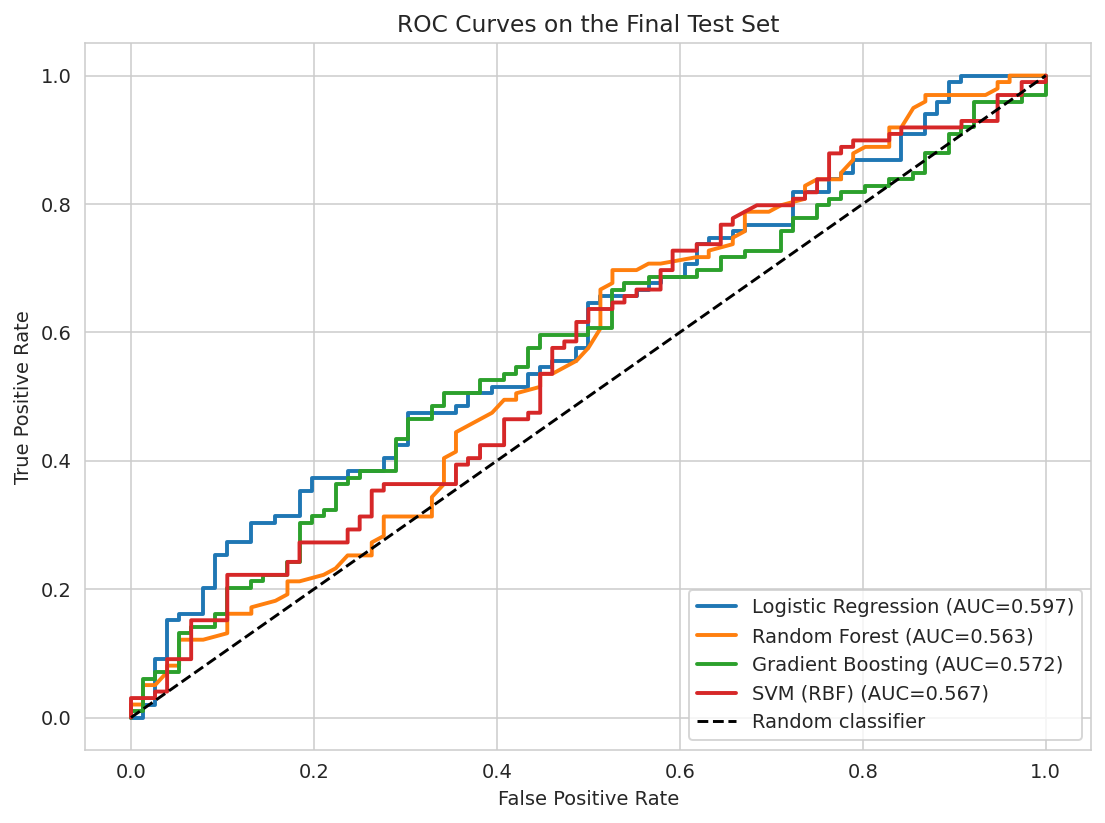

In [5]:
plt.figure(figsize=(8, 6))
for name, probability in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auc_value = roc_auc_score(y_test, probability)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on the Final Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6.5 Selected Model Metrics and Calibration

In [6]:
raw_probability = selected_model.predict_proba(X_test)[:, 1]
raw_prediction = (raw_probability >= decision_threshold).astype(int)
calibrated_probability = calibrated_model.predict_proba(X_test)[:, 1]

# Calibration changes probability quality, while the Task 05 class threshold remains fixed.
calibrated_prediction = (calibrated_probability >= decision_threshold).astype(int)

comparison_df = pd.DataFrame([
    {
        'Version': 'Raw selected model',
        'Accuracy': accuracy_score(y_test, raw_prediction),
        'Precision': precision_score(y_test, raw_prediction, zero_division=0),
        'Recall': recall_score(y_test, raw_prediction, zero_division=0),
        'F1 Score': f1_score(y_test, raw_prediction, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, raw_probability),
        'Brier Score': brier_score_loss(y_test, raw_probability)
    },
    {
        'Version': 'Validation-calibrated model',
        'Accuracy': accuracy_score(y_test, calibrated_prediction),
        'Precision': precision_score(y_test, calibrated_prediction, zero_division=0),
        'Recall': recall_score(y_test, calibrated_prediction, zero_division=0),
        'F1 Score': f1_score(y_test, calibrated_prediction, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, calibrated_probability),
        'Brier Score': brier_score_loss(y_test, calibrated_probability)
    }
])
display(comparison_df.round(4))

# The selected model and class decisions remain those fixed in Task 05.
final_prediction = raw_prediction
final_probability = calibrated_probability

print(classification_report(
    y_test, final_prediction,
    target_names=['Attended (0)', 'No-Show (1)'], zero_division=0
))

              precision    recall  f1-score   support

Attended (0)       0.60      0.16      0.25        76
 No-Show (1)       0.59      0.92      0.72        99

    accuracy                           0.59       175
   macro avg       0.59      0.54      0.48       175
weighted avg       0.59      0.59      0.51       175



,Version,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Brier Score
0,Raw selected model,0.5886,0.5871,0.9192,0.7165,0.5634,0.2465
1,Validation-calibrated model,0.5771,0.5740,0.9798,0.7239,0.5634,0.2423


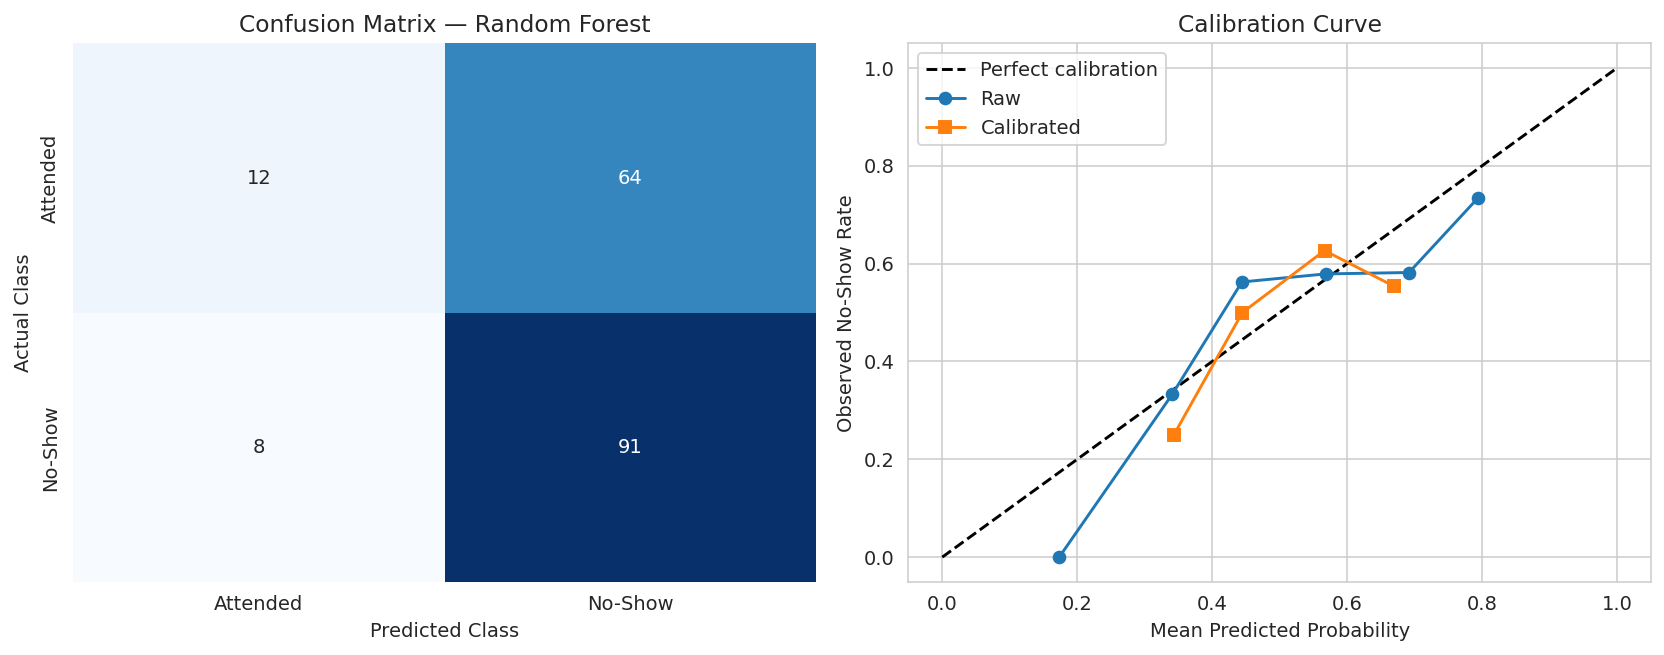

In [7]:
cm = confusion_matrix(y_test, final_prediction)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Attended', 'No-Show'],
            yticklabels=['Attended', 'No-Show'])
axes[0].set_title(f'Confusion Matrix — {selected_model_name}')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('Actual Class')

fraction_raw, mean_raw = calibration_curve(y_test, raw_probability, n_bins=8)
fraction_cal, mean_cal = calibration_curve(y_test, calibrated_probability, n_bins=8)
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1].plot(mean_raw, fraction_raw, marker='o', label='Raw')
axes[1].plot(mean_cal, fraction_cal, marker='s', label='Calibrated')
axes[1].set_title('Calibration Curve')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Observed No-Show Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:** Accuracy and F1 show class-prediction performance, while ROC-AUC shows ranking ability. The Brier score measures probability error. Calibration does not change which model was selected. Moderate results mean the system should support reminder decisions, not make automatic clinical decisions.

## 6.6 Fairness Evaluation

,Attribute,Group,Support,Recall,False Positive Rate,Brier Score
0,gender,Male,85,0.8478,0.7436,0.2433
1,gender,Female,90,0.9811,0.9459,0.2414
2,age_group,18-39,60,0.9143,0.8800,0.2493
3,age_group,60+,37,0.9167,0.7692,0.2194
4,age_group,40-59,70,0.9412,0.8333,0.2508
5,age_group,0-17,8,0.8333,1.0000,0.2218


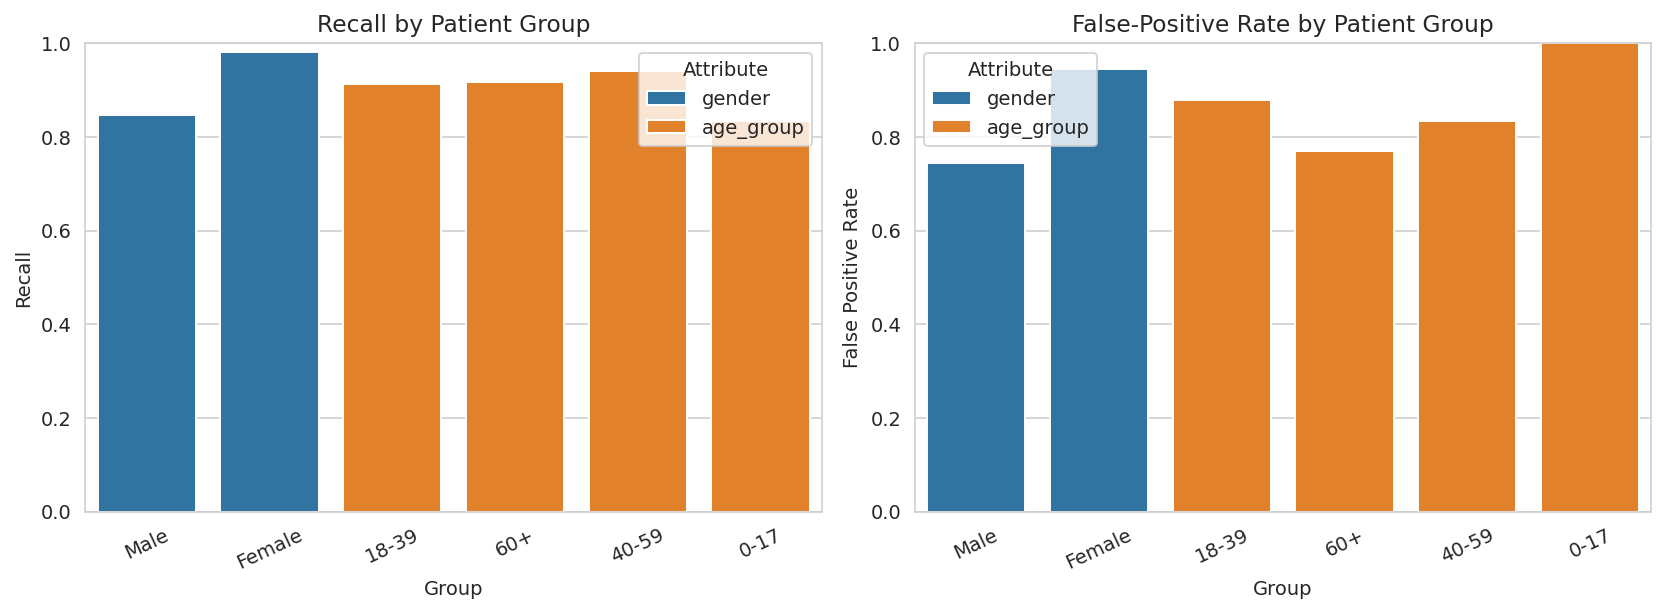

In [8]:
def subgroup_results(attribute):
    rows = []
    for group in fair_test[attribute].dropna().unique():
        mask = fair_test[attribute].eq(group).to_numpy()
        group_y = y_test.to_numpy()[mask]
        group_pred = final_prediction[mask]
        group_prob = final_probability[mask]
        tn, fp, fn, tp = confusion_matrix(group_y, group_pred, labels=[0, 1]).ravel()
        rows.append({
            'Attribute': attribute, 'Group': str(group), 'Support': len(group_y),
            'Recall': tp / (tp + fn) if tp + fn else np.nan,
            'False Positive Rate': fp / (fp + tn) if fp + tn else np.nan,
            'Brier Score': brier_score_loss(group_y, group_prob)
        })
    return pd.DataFrame(rows)

fairness_df = pd.concat([
    subgroup_results('gender'), subgroup_results('age_group')
], ignore_index=True)
display(fairness_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=fairness_df, x='Group', y='Recall', hue='Attribute', ax=axes[0])
axes[0].set_title('Recall by Patient Group')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylim(0, 1)
sns.barplot(data=fairness_df, x='Group', y='False Positive Rate', hue='Attribute', ax=axes[1])
axes[1].set_title('False-Positive Rate by Patient Group')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Justification:** Gender and age group are used only to monitor performance differences. Small groups produce unstable results, so subgroup gaps should be reported as limitations rather than proof of discrimination.

## 6.7 Save Evaluation Results

In [9]:
joblib.dump(calibrated_model, MODEL_DIR / 'calibrated_probability_model.pkl')
test_df.to_csv(MODEL_DIR / 'task06_model_evaluation.csv', index=False)
comparison_df.to_csv(MODEL_DIR / 'task06_calibration_comparison.csv', index=False)
fairness_df.to_csv(MODEL_DIR / 'task06_fairness_metrics.csv', index=False)
print('Task 06 results saved successfully.')

Task 06 results saved successfully.


### Task 06 Summary

- The model and threshold were fixed before test evaluation.
- Four models were reported in one final test pass.
- Accuracy, precision, recall, F1, ROC-AUC, confusion matrix, and classification report were included.
- Calibration was fitted only on validation data and assessed with a calibration curve and Brier score.
- Recall, false-positive rate, and Brier score were checked across gender and age groups.